# Clasificación Multiclase con Redes Neuronales en PyTorch

Este cuadernillo es una adaptación del laboratorio de **Regresión Logística Multiclase (One-vs-All)** a **Redes Neuronales con PyTorch**.

## Objetivos:
- Implementar clasificación multiclase usando `torch.nn`
- Utilizar `Dataset` y `DataLoader` para manejo de datos
- Implementar **checkpoints** para guardar/cargar modelos
- Clasificar tráfico de red (Dataset NSL-KDD)

## Dataset NSL-KDD:
- **122 características** de tráfico de red
- **3 clases** (trabajamos con las más representativas):
  - **0 → Normal**: Tráfico legítimo
  - **1 → DoS**: Ataque de Denegación de Servicio
  - **2 → Probe**: Escaneo/sondeo de red

## Diferencia clave con Clasificación Binaria:

| Aspecto | Binaria | Multiclase |
|---------|---------|------------|
| Salida | 1 neurona | N neuronas (una por clase) |
| Activación | Sigmoid | **Softmax** |
| Loss | BCELoss | **CrossEntropyLoss** |
| Etiquetas | 0 o 1 | 0, 1, 2, ... N-1 |

## 1. Configuración del Entorno e Importación de Librerías

In [17]:
# Instalar imblearn si no está instalado
!pip install imbalanced-learn -q

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE  # Para balanceo de clases

# Verificar si hay GPU disponible
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


## 2. Carga y Exploración de Datos

In [18]:
# Montar Google Drive (si estás en Colab)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# Definir los nombres de las 43 columnas originales del dataset NSL-KDD
nombres_columnas = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty_level"
]

# Cargar el dataset
ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/sis420/Laboratorios/Lab 4/lab 4(1)/KDDTrain+.txt'
df = pd.read_csv(ruta_dataset, names=nombres_columnas)

# Eliminar columna de dificultad (meta-información)
df = df.drop('difficulty_level', axis=1)

print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset cargado: 125973 filas, 42 columnas


In [20]:
# Mapear los tipos de ataque a 3 clases principales
# (Eliminamos R2L y U2R porque tienen pocos ejemplos)
mapa_clases = {
    # Clase 0: Normal
    'normal': 0,

    # Clase 1: DoS (Denegación de servicio)
    'neptune': 1, 'smurf': 1, 'pod': 1, 'teardrop': 1, 'land': 1,
    'back': 1, 'apache2': 1, 'udpstorm': 1, 'processtable': 1,
    'worm': 1, 'mailbomb': 1,

    # Clase 2: Probe (Escaneo de red)
    'satan': 2, 'ipsweep': 2, 'portsweep': 2, 'nmap': 2,
    'mscan': 2, 'saint': 2
}

# Aplicar el mapa y FILTRAR solo las 3 clases
df['label'] = df['label'].map(mapa_clases)

# Eliminar filas con clases no mapeadas (R2L, U2R, etc.)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

print(f"\nDataset filtrado: {df.shape[0]} filas")
print(f"\nDistribución de clases:")
print(df['label'].value_counts().sort_index())


Dataset filtrado: 124926 filas

Distribución de clases:
label
0    67343
1    45927
2    11656
Name: count, dtype: int64


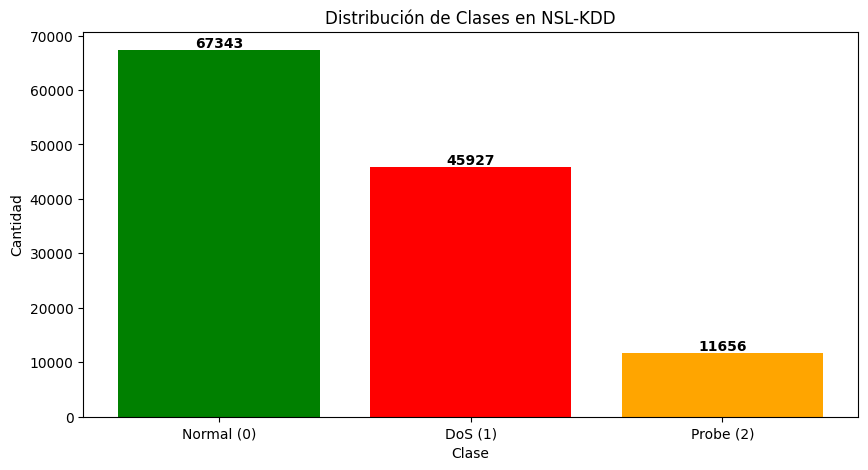

In [21]:
# Visualizar distribución de clases
nombres_clases = ['Normal (0)', 'DoS (1)', 'Probe (2)']
colores = ['green', 'red', 'orange']

plt.figure(figsize=(10, 5))
conteos = df['label'].value_counts().sort_index()
plt.bar(nombres_clases, conteos.values, color=colores)
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.title('Distribución de Clases en NSL-KDD')

# Añadir valores encima de las barras
for i, v in enumerate(conteos.values):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.show()

## 3. Preprocesamiento de Datos

In [22]:
# One-Hot Encoding para columnas categóricas
# Convierte texto (protocol_type, service, flag) en columnas binarias
df = pd.get_dummies(df, columns=['protocol_type', 'service', 'flag'], dtype=float)

print(f"Después de One-Hot Encoding: {df.shape[1]} columnas")

Después de One-Hot Encoding: 123 columnas


In [23]:
# Separar características (X) y etiquetas (y)
X_completo = df.drop('label', axis=1).values.astype(np.float32)
y_completo = df['label'].values.astype(np.int64)  # CrossEntropyLoss requiere int64

print(f"Forma de X: {X_completo.shape}")
print(f"Forma de y: {y_completo.shape}")
print(f"Número de características: {X_completo.shape[1]}")

Forma de X: (124926, 122)
Forma de y: (124926,)
Número de características: 122


In [24]:
# Función de normalización Z-score
def normalizar(data):
    """
    Normaliza los datos usando Z-score: z = (x - mu) / sigma
    """
    mu = np.mean(data, axis=0)
    sigma = np.std(data, axis=0)
    # Evitar división por cero
    sigma[sigma == 0] = 1
    data_norm = (data - mu) / sigma
    return data_norm, mu, sigma

# Normalizar X
X_norm, mu_X, sigma_X = normalizar(X_completo)

print(f"Datos normalizados correctamente")
print(f"Media de X (primeras 5): {mu_X[:5]}")

Datos normalizados correctamente
Media de X (primeras 5): [2.8447247e+02 4.3497293e+04 1.9291055e+04 2.0011848e-04 2.2877544e-02]


In [25]:
# ============================================================
# BALANCEO DE CLASES CON SMOTE
# ============================================================
# Meta: 20,000 ejemplos por clase = 60,000 total
#
# SMOTE (Synthetic Minority Over-sampling Technique):
# - Genera ejemplos sintéticos para clases minoritarias
# - Interpola entre ejemplos existentes de la misma clase
# - Mejor que duplicar porque crea variedad
# ============================================================

MUESTRAS_POR_CLASE = 20000

print("Distribución ANTES del balanceo:")
for i in range(3):
    count = np.sum(y_completo == i)
    print(f"  Clase {i}: {count}")

# Paso 1: Reducir clases mayoritarias a 20,000 (undersampling)
# Paso 2: Aumentar clases minoritarias a 20,000 con SMOTE (oversampling)

np.random.seed(42)

# Primero hacemos undersampling manual de las clases mayoritarias
indices_por_clase = []
for i in range(3):
    idx_clase = np.where(y_completo == i)[0]
    if len(idx_clase) > MUESTRAS_POR_CLASE:
        # Undersampling: tomar solo 20,000 aleatorios
        idx_clase = np.random.choice(idx_clase, MUESTRAS_POR_CLASE, replace=False)
    indices_por_clase.append(idx_clase)

# Combinar índices seleccionados
indices_seleccionados = np.concatenate(indices_por_clase)
X_temp = X_norm[indices_seleccionados]
y_temp = y_completo[indices_seleccionados]

print(f"\nDespués de undersampling:")
for i in range(3):
    print(f"  Clase {i}: {np.sum(y_temp == i)}")

# Ahora aplicamos SMOTE para aumentar clases minoritarias a 20,000
smote = SMOTE(
    sampling_strategy={0: MUESTRAS_POR_CLASE, 1: MUESTRAS_POR_CLASE, 2: MUESTRAS_POR_CLASE},
    random_state=42,
    k_neighbors=5  # Número de vecinos para interpolación
)

X_balanceado, y_balanceado = smote.fit_resample(X_temp, y_temp)

print(f"\nDistribución DESPUÉS del balanceo con SMOTE:")
for i in range(3):
    print(f"  Clase {i}: {np.sum(y_balanceado == i)}")
print(f"\nTotal de ejemplos: {len(y_balanceado)}")

Distribución ANTES del balanceo:
  Clase 0: 67343
  Clase 1: 45927
  Clase 2: 11656

Después de undersampling:
  Clase 0: 20000
  Clase 1: 20000
  Clase 2: 11656

Distribución DESPUÉS del balanceo con SMOTE:
  Clase 0: 20000
  Clase 1: 20000
  Clase 2: 20000

Total de ejemplos: 60000


In [26]:
# ============================================================
# DIVISIÓN 70/20/10 PARA EVITAR DATA LEAKAGE
# ============================================================
# - 70% Entrenamiento: para entrenar el modelo
# - 20% Validación: para seleccionar el mejor modelo (checkpoints)
# - 10% Test: evaluación FINAL (solo se usa UNA vez al final)
#
# ¿Por qué esto evita Data Leakage?
# Antes usábamos test para elegir el mejor modelo → el modelo
# indirectamente "veía" datos de test durante el entrenamiento.
# Ahora usamos validación para elegir, test queda "oculto".
# ============================================================

# Primero separamos 10% para test (evaluación final)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_balanceado, y_balanceado,
    test_size=0.10,
    random_state=42,
    stratify=y_balanceado
)

# Del 90% restante: 70% train, 20% validación
# 20/(70+20) = 20/90 ≈ 0.222
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.222,  # 20% del total original
    random_state=42,
    stratify=y_temp
)

print("División de datos (70/20/10):")
print(f"  Entrenamiento: {X_train.shape[0]} ejemplos ({100*X_train.shape[0]/len(y_balanceado):.1f}%)")
print(f"  Validación:    {X_val.shape[0]} ejemplos ({100*X_val.shape[0]/len(y_balanceado):.1f}%)")
print(f"  Test (final):  {X_test.shape[0]} ejemplos ({100*X_test.shape[0]/len(y_balanceado):.1f}%)")

print(f"\nClases en entrenamiento:")
for i in range(3):
    print(f"  Clase {i}: {np.sum(y_train==i)}")

print(f"\nClases en validación:")
for i in range(3):
    print(f"  Clase {i}: {np.sum(y_val==i)}")

print(f"\nClases en test:")
for i in range(3):
    print(f"  Clase {i}: {np.sum(y_test==i)}")

División de datos (70/20/10):
  Entrenamiento: 42012 ejemplos (70.0%)
  Validación:    11988 ejemplos (20.0%)
  Test (final):  6000 ejemplos (10.0%)

Clases en entrenamiento:
  Clase 0: 14004
  Clase 1: 14004
  Clase 2: 14004

Clases en validación:
  Clase 0: 3996
  Clase 1: 3996
  Clase 2: 3996

Clases en test:
  Clase 0: 2000
  Clase 1: 2000
  Clase 2: 2000


## 4. Creación del Dataset Personalizado (PyTorch)

In [27]:
class NSLKDDDataset(torch.utils.data.Dataset):
    """
    Dataset personalizado para datos de NSL-KDD.
    Hereda de torch.utils.data.Dataset
    """
    def __init__(self, X, y):
        """
        Constructor: convierte numpy arrays a tensores de PyTorch
        """
        self.X = torch.from_numpy(X).float()
        # Para CrossEntropyLoss, y debe ser Long (int64) y 1D
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        """
        Retorna el número de muestras en el dataset
        """
        return len(self.X)

    def __getitem__(self, idx):
        """
        Retorna una muestra específica (X, y) dado un índice
        """
        return self.X[idx], self.y[idx]

In [28]:
# Crear datasets para train, validación y test
train_dataset = NSLKDDDataset(X_train, y_train)
val_dataset = NSLKDDDataset(X_val, y_val)
test_dataset = NSLKDDDataset(X_test, y_test)

print(f"Tamaño del dataset de entrenamiento: {len(train_dataset)}")
print(f"Tamaño del dataset de validación: {len(val_dataset)}")
print(f"Tamaño del dataset de prueba (final): {len(test_dataset)}")

# Verificar una muestra
sample_x, sample_y = train_dataset[0]
print(f"\nMuestra - X shape: {sample_x.shape}, y (clase): {sample_y.item()}")

Tamaño del dataset de entrenamiento: 42012
Tamaño del dataset de validación: 11988
Tamaño del dataset de prueba (final): 6000

Muestra - X shape: torch.Size([122]), y (clase): 2


## 5. Creación de DataLoaders

In [29]:
# Hiperparámetros
BATCH_SIZE = 512

# Crear DataLoaders
# train_loader: shuffle=True (mezclar datos de entrenamiento)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# val_loader: para selección de modelo (checkpoints)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# test_loader: SOLO para evaluación final (evita data leakage)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Verificar un batch
x_batch, y_batch = next(iter(train_loader))
print(f"Batch X shape: {x_batch.shape}")
print(f"Batch y shape: {y_batch.shape}")
print(f"Ejemplo de etiquetas en batch: {y_batch[:10]}")

Batch X shape: torch.Size([512, 122])
Batch y shape: torch.Size([512])
Ejemplo de etiquetas en batch: tensor([1, 1, 0, 1, 0, 0, 2, 2, 0, 0])


## 6. Definición del Modelo de Red Neuronal

Para **Clasificación Multiclase**, usamos:
- Capas ocultas con ReLU
- **N neuronas de salida** (una por cada clase)
- **Softmax** para convertir salidas a probabilidades (incluido en CrossEntropyLoss)

### ¿Qué es Softmax?

Convierte N valores en N probabilidades que suman 1:

```
softmax(zᵢ) = e^zᵢ / Σe^zⱼ

Ejemplo:
  z = [2.0, 1.0, 0.1]
  e^z = [7.39, 2.72, 1.10]
  suma = 11.21
  softmax = [0.66, 0.24, 0.10]  ← Probabilidades que suman 1
```

In [30]:
class ClasificadorMulticlaseNN(nn.Module):
    """
    Red Neuronal para Clasificación Multiclase con técnicas anti-overfitting.

    Mejoras aplicadas:
    - Dropout: Desactiva neuronas aleatoriamente durante entrenamiento
    - BatchNorm: Normaliza activaciones (entrenamiento más estable)
    """
    def __init__(self, n_features, n_classes, dropout_rate=0.3):
        super(ClasificadorMulticlaseNN, self).__init__()

        self.red = nn.Sequential(
            # Capa 1: entrada → 128 neuronas
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),  # Normaliza las activaciones
            nn.ReLU(),
            nn.Dropout(dropout_rate),  # Desactiva 30% de neuronas (evita memorización)

            # Capa 2: 128 → 64 neuronas
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Capa 3: 64 → 32 neuronas
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),  # Menos dropout cerca de salida

            # Capa de salida: N clases
            nn.Linear(32, n_classes)
        )

    def forward(self, x):
        return self.red(x)

In [31]:
# Número de características y clases
n_features = X_train.shape[1]
n_classes = 3  # Normal, DoS, Probe

print(f"Número de características: {n_features}")
print(f"Número de clases: {n_classes}")

# Crear el modelo y moverlo al dispositivo
model = ClasificadorMulticlaseNN(n_features, n_classes).to(device)
print(f"\nArquitectura del modelo:")
print(model)

Número de características: 122
Número de clases: 3

Arquitectura del modelo:
ClasificadorMulticlaseNN(
  (red): Sequential(
    (0): Linear(in_features=122, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.15, inplace=False)
    (12): Linear(in_features=32, out_features=3, bias=True)
  )
)


## 7. Configuración del Entrenamiento

Para clasificación multiclase usamos:
- **CrossEntropyLoss**: Combina Softmax + Negative Log Likelihood
- **Adam**: Optimizador adaptativo

### ¿Qué hace CrossEntropyLoss?

```
1. Aplica Softmax a los logits → probabilidades
2. Calcula: Loss = -log(probabilidad de la clase correcta)

Ejemplo:
  Logits = [2.0, 1.0, 0.1]  (3 clases)
  Softmax = [0.66, 0.24, 0.10]
  
  Si clase_real = 0:
    Loss = -log(0.66) = 0.42  ← bajo (bien predicho)
  
  Si clase_real = 2:
    Loss = -log(0.10) = 2.30  ← alto (mal predicho)
```

In [32]:
# Hiperparámetros de entrenamiento
LEARNING_RATE = 0.001
EPOCHS = 100  # Más épocas porque tenemos early stopping
WEIGHT_DECAY = 1e-4  # Regularización L2 (penaliza pesos grandes)

# Función de pérdida
criterion = nn.CrossEntropyLoss()

# Optimizador con weight_decay (regularización L2)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY  # Penaliza pesos grandes → evita overfitting
)

# Scheduler: reduce learning rate cuando val_loss no mejora
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',      # Minimizar val_loss
    factor=0.5,      # Reduce LR a la mitad
    patience=5       # Espera 5 épocas sin mejora
)  # Nota: 'verbose' fue eliminado en PyTorch 2.x

print(f"Learning Rate inicial: {LEARNING_RATE}")
print(f"Weight Decay (L2): {WEIGHT_DECAY}")
print(f"Epochs máximos: {EPOCHS}")
print(f"Scheduler: ReduceLROnPlateau (reduce LR si no mejora)")

Learning Rate inicial: 0.001
Weight Decay (L2): 0.0001
Epochs máximos: 100
Scheduler: ReduceLROnPlateau (reduce LR si no mejora)


## 8. Bucle de Entrenamiento con Checkpoints

In [33]:
def entrenar(model, train_loader, val_loader, criterion, optimizer, epochs, device,
             checkpoint_path="./mejor_modelo_multiclase.pt", patience=10, scheduler=None):
    """
    Función de entrenamiento con:
    - Checkpoints (guarda mejor modelo)
    - Early Stopping (detiene si no mejora)
    - Learning Rate Scheduler (reduce LR adaptivamente)

    Args:
        patience: Épocas sin mejora antes de detener
        scheduler: Opcional - reduce learning rate cuando no mejora
    """
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    best_val_loss = float('inf')
    epochs_sin_mejora = 0
    mejor_epoca = 0

    for epoch in range(1, epochs + 1):
        # --- ENTRENAMIENTO ---
        model.train()
        epoch_train_loss = []
        epoch_train_correct = 0
        epoch_train_total = 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_train_loss.append(loss.item())
            _, predicted = torch.max(logits, 1)
            epoch_train_correct += (predicted == y_batch).sum().item()
            epoch_train_total += y_batch.size(0)

        avg_train_loss = np.mean(epoch_train_loss)
        train_acc = epoch_train_correct / epoch_train_total
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)

        # --- VALIDACIÓN ---
        model.eval()
        epoch_val_loss = []
        epoch_val_correct = 0
        epoch_val_total = 0

        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                logits = model(x_batch)
                loss = criterion(logits, y_batch)

                epoch_val_loss.append(loss.item())
                _, predicted = torch.max(logits, 1)
                epoch_val_correct += (predicted == y_batch).sum().item()
                epoch_val_total += y_batch.size(0)

        avg_val_loss = np.mean(epoch_val_loss)
        val_acc = epoch_val_correct / epoch_val_total
        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)

        # --- SCHEDULER: Ajustar learning rate ---
        if scheduler is not None:
            scheduler.step(avg_val_loss)

        # --- CHECKPOINT + EARLY STOPPING ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            mejor_epoca = epoch
            epochs_sin_mejora = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Epoch {epoch}/{epochs} - Loss: {avg_train_loss:.4f} - Acc: {train_acc:.4f} - Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.4f} ✓")
        else:
            epochs_sin_mejora += 1
            if epoch % 5 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(f"Epoch {epoch}/{epochs} - Loss: {avg_train_loss:.4f} - Acc: {train_acc:.4f} - Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.4f} (LR: {current_lr:.6f})")

        # Early stopping
        if epochs_sin_mejora >= patience:
            print(f"\n⚠️ Early Stopping en época {epoch} (sin mejora por {patience} épocas)")
            break

    print(f"\n" + "="*50)
    print(f"RESUMEN DEL ENTRENAMIENTO")
    print(f"="*50)
    print(f"Mejor Val Loss: {best_val_loss:.4f} (época {mejor_epoca})")
    print(f"Épocas entrenadas: {len(train_losses)}")
    return train_losses, val_losses, train_accs, val_accs

In [34]:
# Entrenar el modelo con todas las mejoras
CHECKPOINT_PATH = "./checkpoint_multiclase.pt"
PATIENCE = 15  # Early stopping después de 15 épocas sin mejora

train_losses, val_losses, train_accs, val_accs = entrenar(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    device=device,
    checkpoint_path=CHECKPOINT_PATH,
    patience=PATIENCE,
    scheduler=scheduler  # Reduce LR automáticamente
)

Epoch 1/100 - Loss: 0.4188 - Acc: 0.8986 - Val Loss: 0.1262 - Val Acc: 0.9717 ✓
Epoch 2/100 - Loss: 0.1093 - Acc: 0.9773 - Val Loss: 0.0658 - Val Acc: 0.9831 ✓
Epoch 3/100 - Loss: 0.0610 - Acc: 0.9863 - Val Loss: 0.0337 - Val Acc: 0.9912 ✓
Epoch 4/100 - Loss: 0.0407 - Acc: 0.9906 - Val Loss: 0.0270 - Val Acc: 0.9933 ✓
Epoch 5/100 - Loss: 0.0326 - Acc: 0.9919 - Val Loss: 0.0221 - Val Acc: 0.9941 ✓
Epoch 6/100 - Loss: 0.0291 - Acc: 0.9926 - Val Loss: 0.0192 - Val Acc: 0.9947 ✓
Epoch 7/100 - Loss: 0.0264 - Acc: 0.9930 - Val Loss: 0.0175 - Val Acc: 0.9947 ✓
Epoch 9/100 - Loss: 0.0227 - Acc: 0.9937 - Val Loss: 0.0169 - Val Acc: 0.9943 ✓
Epoch 10/100 - Loss: 0.0227 - Acc: 0.9935 - Val Loss: 0.0162 - Val Acc: 0.9946 ✓
Epoch 11/100 - Loss: 0.0234 - Acc: 0.9944 - Val Loss: 0.0141 - Val Acc: 0.9951 ✓
Epoch 14/100 - Loss: 0.0182 - Acc: 0.9946 - Val Loss: 0.0140 - Val Acc: 0.9942 ✓
Epoch 15/100 - Loss: 0.0173 - Acc: 0.9949 - Val Loss: 0.0143 - Val Acc: 0.9946 (LR: 0.001000)
Epoch 16/100 - Loss: 0.

## 9. Visualización del Entrenamiento

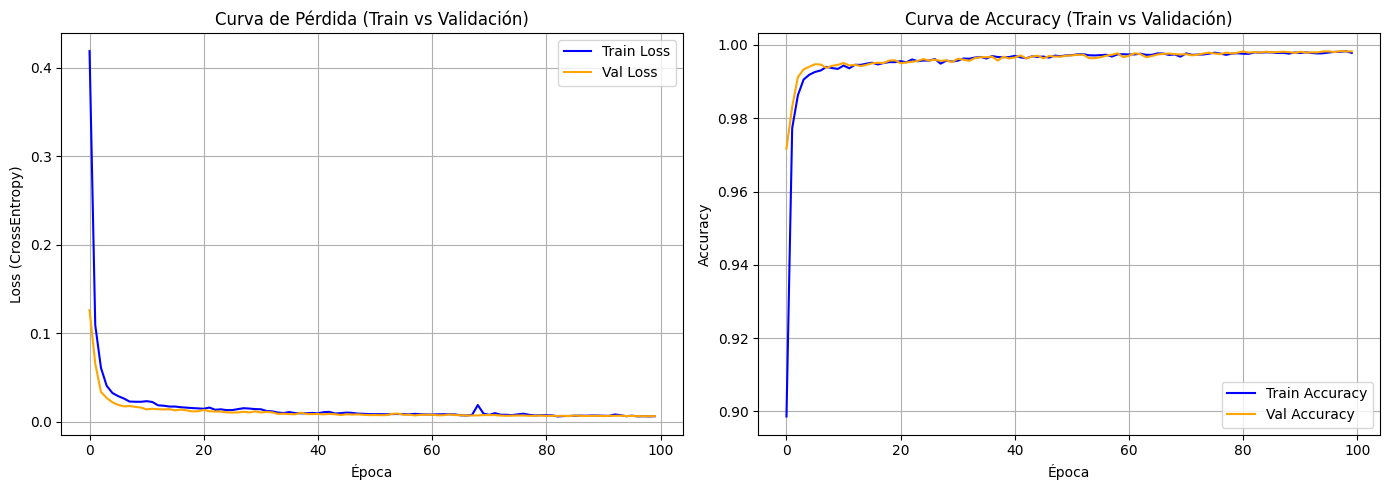

In [35]:
# Graficar curvas de pérdida y accuracy (Train vs Validación)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Loss
axes[0].plot(train_losses, label='Train Loss', color='blue')
axes[0].plot(val_losses, label='Val Loss', color='orange')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (CrossEntropy)')
axes[0].set_title('Curva de Pérdida (Train vs Validación)')
axes[0].legend()
axes[0].grid(True)

# Gráfico de Accuracy
axes[1].plot(train_accs, label='Train Accuracy', color='blue')
axes[1].plot(val_accs, label='Val Accuracy', color='orange')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Curva de Accuracy (Train vs Validación)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 10. Cargar el Mejor Modelo (Checkpoint)

In [36]:
# Cargar el mejor modelo desde el checkpoint
model_loaded = ClasificadorMulticlaseNN(n_features, n_classes).to(device)
model_loaded.load_state_dict(torch.load(CHECKPOINT_PATH))
model_loaded.eval()

print("Modelo cargado desde checkpoint exitosamente!")

Modelo cargado desde checkpoint exitosamente!


## 11. Evaluación FINAL con Conjunto de Test\n
\n
**IMPORTANTE**: Esta es la primera y única vez que usamos el conjunto de test.\n
Durante el entrenamiento usamos validación para seleccionar el modelo.\n
Esto evita **data leakage** (el modelo no ha 'visto' test durante el entrenamiento).

In [37]:
def evaluar_final(model, test_loader, device):
    """
    Evaluación FINAL con el conjunto de test.
    Se usa SOLO UNA VEZ al final del proceso.
    """
    model.eval()
    predicciones = []
    probabilidades = []
    reales = []
    total_loss = []
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch_dev = y_batch.to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch_dev)
            total_loss.append(loss.item())

            probs = torch.softmax(logits, dim=1)  # Convertir a probabilidades
            _, preds = torch.max(logits, 1)  # Clase predicha (argmax)

            probabilidades.extend(probs.cpu().numpy())
            predicciones.extend(preds.cpu().numpy())
            reales.extend(y_batch.numpy())

    avg_loss = np.mean(total_loss)
    return np.array(predicciones), np.array(probabilidades), np.array(reales), avg_loss

# Evaluación final con el conjunto de TEST (nunca visto durante entrenamiento)
print("="*60)
print("EVALUACIÓN FINAL CON CONJUNTO DE TEST")
print("(Primera y única vez que se usa este conjunto)")
print("="*60)

y_pred, y_prob, y_real, test_loss = evaluar_final(model_loaded, test_loader, device)
test_acc = accuracy_score(y_real, y_pred)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

EVALUACIÓN FINAL CON CONJUNTO DE TEST
(Primera y única vez que se usa este conjunto)

Test Loss: 0.0073
Test Accuracy: 0.9977 (99.77%)


In [38]:
# Reporte de clasificación detallado
print(f"\n{'='*50}")
print(f"REPORTE DE CLASIFICACIÓN")
print(f"{'='*50}")
print(classification_report(y_real, y_pred, target_names=['Normal', 'DoS', 'Probe']))


REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2000
         DoS       1.00      1.00      1.00      2000
       Probe       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



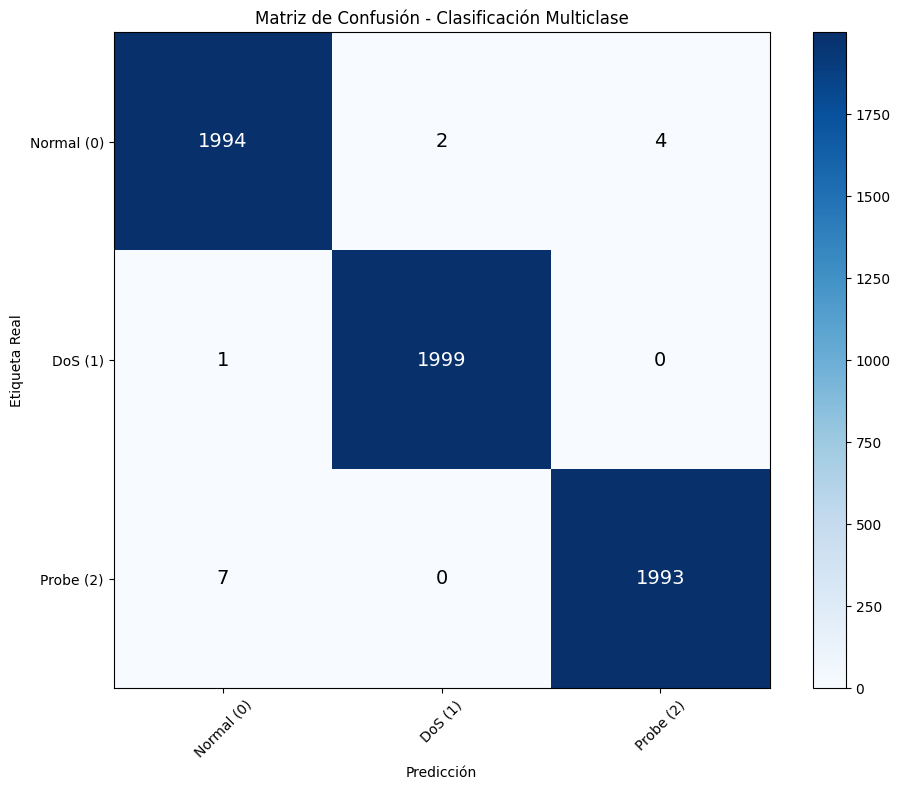


Desglose por clase:
Normal (0): 1994/2000 correctos (99.7%)
DoS (1): 1999/2000 correctos (100.0%)
Probe (2): 1993/2000 correctos (99.7%)


In [39]:
# Matriz de confusión
cm = confusion_matrix(y_real, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Clasificación Multiclase')
plt.colorbar()

classes = ['Normal (0)', 'DoS (1)', 'Probe (2)']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Añadir valores en cada celda
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=14)

plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

# Mostrar valores por clase
print("\nDesglose por clase:")
for i, clase in enumerate(classes):
    total_real = cm[i, :].sum()
    correctos = cm[i, i]
    print(f"{clase}: {correctos}/{total_real} correctos ({correctos/total_real*100:.1f}%)")

## 12. Predicción de Nuevo Tráfico

In [40]:
def predecir_trafico(model, caracteristicas, mu_X, sigma_X, device):
    """
    Predice el tipo de tráfico de red.

    Args:
        model: Modelo entrenado
        caracteristicas: numpy array con las características del tráfico
        mu_X, sigma_X: Media y desv. estándar de X (para normalizar)
        device: Dispositivo (cuda/cpu)

    Returns:
        Clase predicha, probabilidades por clase
    """
    nombres_clases = ['Normal', 'DoS', 'Probe']
    model.eval()

    # Normalizar características
    x_norm = (caracteristicas - mu_X) / sigma_X
    x_tensor = torch.from_numpy(x_norm.astype(np.float32)).unsqueeze(0).to(device)

    # Predecir
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        clase = logits.argmax(dim=1).item()

    return clase, nombres_clases[clase], probs

In [41]:
# Ejemplo: Predecir usando un tráfico del dataset de prueba
indice_ejemplo = 100
trafico_ejemplo = X_completo[len(X_train) + indice_ejemplo]  # Sin normalizar
etiqueta_real = y_completo[len(X_train) + indice_ejemplo]

nombres_clases = ['Normal', 'DoS', 'Probe']

clase_pred, nombre_clase, probs = predecir_trafico(
    model=model_loaded,
    caracteristicas=trafico_ejemplo,
    mu_X=mu_X,
    sigma_X=sigma_X,
    device=device
)

print(f"\n{'='*50}")
print(f"PREDICCIÓN DE TRÁFICO DE RED")
print(f"{'='*50}")
print(f"\nEtiqueta Real: {nombres_clases[etiqueta_real]} ({etiqueta_real})")
print(f"Predicción: {nombre_clase} ({clase_pred})")
print(f"\nProbabilidades por clase:")
for i, (nombre, prob) in enumerate(zip(nombres_clases, probs)):
    barra = '█' * int(prob * 30)
    print(f"  {nombre:10s}: {prob:.4f} ({prob*100:5.1f}%) {barra}")
print(f"\nResultado: {'✓ CORRECTO' if clase_pred == etiqueta_real else '✗ INCORRECTO'}")
print(f"{'='*50}")


PREDICCIÓN DE TRÁFICO DE RED

Etiqueta Real: DoS (1)
Predicción: DoS (1)

Probabilidades por clase:
  Normal    : 0.0000 (  0.0%) 
  DoS       : 1.0000 (100.0%) █████████████████████████████
  Probe     : 0.0000 (  0.0%) 

Resultado: ✓ CORRECTO


## 13. Resumen

### Conceptos Clave Implementados:

1. **Clasificación Multiclase**: Predecir entre N > 2 clases
2. **`torch.nn.CrossEntropyLoss`**: Softmax + Negative Log Likelihood
3. **N neuronas de salida**: Una por cada clase
4. **`torch.max(logits, 1)`**: Obtener la clase predicha (argmax)
5. **`stratify`** en train_test_split: Mantener proporción de clases

### Comparación: Binaria vs Multiclase

| Aspecto | Binaria (MiniBooNE) | Multiclase (NSL-KDD) |
|---------|---------------------|----------------------|
| Clases | 2 (0 o 1) | 3+ (0, 1, 2, ...) |
| Salida del modelo | 1 neurona | N neuronas |
| Activación | Sigmoid | Softmax (en loss) |
| Loss | BCELoss | CrossEntropyLoss |
| Predicción | `prob > 0.5` | `argmax(logits)` |
| Etiquetas y | float [0, 1] | int64 [0, 1, ..., N-1] |

### Arquitectura de la Red:

```
Entrada (122) → Linear(128) → ReLU → Linear(64) → ReLU → Linear(32) → ReLU → Linear(3) → Logits
                                                                                    ↓
                                                                              CrossEntropyLoss
                                                                              (aplica Softmax)
                                                                                    ↓
                                                                              Probabilidades
                                                                              [P(Normal), P(DoS), P(Probe)]
```